# Notebook 08 — Conclusões e Recomendações de Saúde Pública

## Objetivo
Síntese narrativa do projeto: do tratamento de dados às recomendações de saúde pública. Este notebook fecha o ciclo conectando os achados da EDA (Fase 3), do modelo preditivo (Fases 4-6) e propondo intervenções acionáveis.

## Inputs
- Tudo que foi produzido nas Fases 0-6: dataset limpo, modelo treinado, 7 figuras de avaliação e 19 figuras da EDA.
- `models/best_model.joblib` — XGBoost tuned (AUC-PR 0,5531 / AUC-ROC 0,9055)

## Estrutura
1. **Recapitulação do problema** — o que foi solicitado e o que foi entregue
2. **Top 5 insights da EDA** — achados descritivos com magnitudes
3. **Resultados do modelo** — métricas, threshold operacional, equidade
4. **Top 5 fatores de risco identificados** — SHAP e EDA cruzados
5. **Recomendações de saúde pública** — 5 intervenções acionáveis
6. **Limitações e próximos passos**

> Este notebook não recria figuras — referencia as 38 figuras já produzidas em `reports/figures/`. Uma figura nova é gerada ao final: o **mapa de calor de risco multivariado** (idade × suporte ventilatório), que sintetiza visualmente o sinal predito pelo modelo.

In [1]:
import sys
from pathlib import Path

_src = Path("..") / "src"
if str(_src.resolve()) not in sys.path:
    sys.path.insert(0, str(_src.resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

from maxpar_srag import config

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "figure.dpi": 100, "axes.unicode_minus": False})

FIGURES_DIR = config.FIGURES_DIR / "08_conclusoes"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = config.RANDOM_STATE

print(f"Figuras -> {FIGURES_DIR}")

Figuras -> A:\Repos\Maxpar\reports\figures\08_conclusoes


## 1. Recapitulação do problema

### Escopo do trabalho
A análise teve como objeto a base **SRAG 2023 (Open Data SUS / SIVEP-Gripe)** com quatro dimensões principais de entrega:

1. **Tratamento de dados** — identificar e corrigir problemas, documentar etapas
2. **Análise descritiva** — atributos principais, tendências temporais, distribuição geográfica, fatores de risco e comorbidades
3. **Modelos de ML** — prever evolução do caso (óbito versus cura), avaliar métricas, priorizar transparência
4. **Conclusão** — insights e sugestões de intervenções de saúde pública

### O que foi entregue

| Fase | Notebook | Entrega-chave |
|---|---|---|
| 0 — Setup | — | Estrutura híbrida (notebooks + `src/`), Parquet em `data/raw/` |
| 1 — Profiling | `01_exploracao_inicial.ipynb` | 194 colunas validadas vs dicionário SIVEP-Gripe; range temporal e missing global perfilados |
| 2 — Tratamento | `02_tratamento_dados.ipynb` | `cleaning.py` (10 funções + 29 testes pytest); dataset limpo 276.339 × 185 |
| 3 — EDA | `03_eda_descritiva.ipynb` | 19 figuras cobrindo as 9 dimensões do enunciado |
| 4 — Features | `04_feature_engineering.ipynb` | `features.py`; split temporal 145k treino / 103k teste; 45 features |
| 5 — Modelagem | `05_modelagem_baseline.ipynb` | 8 configurações comparadas (Dummy até XGBoost); XGBoost tuned selecionado |
| 6 — Avaliação | `07_avaliacao_e_interpretacao.ipynb` | Métricas, thresholds operacionais, SHAP, análise de equidade |
| **7 — Síntese** | **`08_conclusoes.ipynb`** (este) | Conclusões, recomendações, entregáveis finais |

### Decisão metodológica central
O **split temporal (1º semestre treino / 2º semestre teste)** foi adotado em vez do split aleatório. Isso simula o uso real do modelo (treinado em dados passados, aplicado a casos futuros) e capta o shift de composição etiológica que ocorreu em 2023 (VSR/Influenza no 1º semestre, COVID no 2º semestre). Um split aleatório teria inflado artificialmente as métricas.

## 2. Top 5 insights da Análise Descritiva

Os 19 painéis da EDA (Fase 3) levantaram dezenas de padrões. Os cinco com maior implicação para política pública estão apresentados a seguir, cada um com magnitude quantificada e ponteiro para a figura correspondente.

---

### Insight 1 — Pico de SRAG em 2023 foi pediátrico, não COVID

A onda de **maio/2023 (semana epidemiológica 21)** registrou 35.248 casos — o maior pico anual. Diferentemente de 2020-2022, o vetor principal foi **VSR e Influenza em crianças com menos de 5 anos**, não COVID. O pico de COVID ocorreu na SE 43 (outubro/novembro), com magnitude bem menor.

**Magnitude:** 42% dos casos SRAG 2023 estão na faixa **0-4 anos**. Mediana de `IDADE_ANOS` = 8 anos.

**Figuras:** `03_eda/02_series_semanais_agente.png` · `03_eda/06_demografia_idade_sexo.png`

O planejamento operacional pós-pandemia (UTI adulto, ventiladores adultos, capacitação em COVID) ficou desalinhado da carga real de 2023, que demanda **UTI pediátrica e leitos clínicos pediátricos**.

---

### Insight 2 — Gradiente etário acentuado na letalidade

A letalidade SRAG cresce monotonicamente da infância à terceira idade:

| Faixa | Letalidade |
|---|---|
| 0-4 anos | 1,2% |
| 5-19 anos | 1,5% |
| 20-39 anos | 8,9% |
| 40-59 anos | 17,0% |
| 60-69 anos | 21,4% |
| 70-79 anos | 23,9% |
| **80+ anos** | **27,7%** |

**Magnitude:** variação de 23 vezes (1,2% para 27,7%). A idade é, isoladamente, o preditor mais forte de mortalidade.

**Figura:** `03_eda/19_letalidade_idade_regiao.png` · `07_avaliacao/05_shap_beeswarm.png` (IDADE_ANOS top-3 no SHAP)

A SRAG se manifesta como doença de duas pontas — incidência alta em crianças, letalidade alta em idosos. Estratégias uniformes falham em ambas as pontas.

---

### Insight 3 — Paradoxo de Simpson na vacinação COVID, resolvido

A análise marginal (sem controlar idade) sugere que **vacinados têm letalidade maior** que não-vacinados (22,5% vs 11,3%, diferença de 11 pontos percentuais). Trata-se de um artefato — os vacinados são mais velhos.

Estratificando por faixa etária, o efeito da vacinação é **protetor em todos os estratos com n >= 100**:

| Faixa | Vacinado - Não vacinado |
|---|---|
| 20-39 anos | -6,5 pp |
| 40-59 anos | -7,7 pp |
| 60-69 anos | -5,2 pp |
| 70-79 anos | -5,1 pp |
| **80+ anos** | **-10,1 pp** |

O heatmap idade × doses confirma resposta-dose: em 80+ anos, a letalidade cai de 36,8% (0 doses) para 26,1% (4 doses) — diferença real de 10 pontos percentuais.

**Figuras:** `03_eda/13_paradoxo_simpson_resolvido.png` · `03_eda/14_letalidade_idade_doses.png`

O resultado é um exemplo de confundimento etário. Justifica modelagem multivariada e cuidado com leitura ingênua de tabelas marginais — armadilha comum em comunicação de saúde pública.

---

### Insight 4 — Suporte ventilatório invasivo é o melhor preditor clínico

Letalidade observada por modalidade de suporte:

| `SUPORT_VEN` | Letalidade |
|---|---|
| Invasivo | **40,95%** |
| Não invasivo | 7,44% |
| Não usou | 4,07% |

Internação em UTI tem efeito similar (18,66% vs 5,79% — 3,2 vezes mais letal). Essas variáveis resultaram, como esperado, nas posições top-1 e top-2 do SHAP.

**Figuras:** `03_eda/15_cuidado_hospitalar.png` · `07_avaliacao/05_shap_beeswarm.png`

Essas variáveis refletem a resposta hospitalar à gravidade observada, não apenas o estado na admissão. Um modelo de triagem na chegada não teria essas features — limitação discutida na seção 5.

---

### Insight 5 — Comorbidades raras e graves têm efeito mais independente que as comuns

A análise univariada mostra cardiopatia com letalidade alta (23,1% vs 13,9% — diferença de 9 pontos percentuais). Ao estratificar por idade, **o gap praticamente desaparece** em adultos e idosos (em 70-79 anos: com cardiopatia 24,4% vs sem 26,8% — diferença de -2,4 pp). O mesmo vale para diabetes.

Comorbidades com **efeito independente mais robusto** (sobrevivem à estratificação por idade):

| Comorbidade | Letalidade observada (marginal) | Prevalência |
|---|---|---|
| Doença hepática | 30,1% | rara |
| Doença renal | 26,6% | rara |
| Imunodepressão | 24,4% | rara |
| Diabetes | 23,6% | cerca de 16% |
| Cardiopatia | 23,1% | **49,1%** |

**Figuras:** `03_eda/10_comorbidades.png` · `03_eda/18_letalidade_idade_comorbidade.png`

Modelos sem `IDADE_ANOS` inflam artificialmente o peso de cardiopatia e diabetes. Recomendações de vigilância devem priorizar comorbidades raras e graves (renal, hepática, imuno) onde o efeito independente é mais robusto.

## 3. Resultados do modelo

Os números abaixo são honestos: hiperparâmetros otimizados via Optuna em CV 3-fold no treino (Jan-Jun/2023); avaliação final no teste temporal (Jul-Dez/2023), nunca visto durante o tuning.

In [2]:
pipeline = joblib.load(config.PROJECT_ROOT / "models" / "best_model.joblib")
X_test = pd.read_parquet(config.DATA_PROCESSED / "X_test.parquet")
y_test = pd.read_parquet(config.DATA_PROCESSED / "y_test.parquet")["target"]

proba = pipeline.predict_proba(X_test)[:, 1]
auc_pr = average_precision_score(y_test, proba)
auc_roc = roc_auc_score(y_test, proba)
brier = brier_score_loss(y_test, proba)

baseline_ap = float(y_test.mean())

print("=== Verificacao das metricas reportadas no STATUS.md ===")
print(f"AUC-PR  : {auc_pr:.4f}   (esperado 0.5531)")
print(f"AUC-ROC : {auc_roc:.4f}   (esperado 0.9055)")
print(f"Brier   : {brier:.4f}   (esperado 0.0915)")
print(f"\nGanho AUC-PR vs baseline aleatorio ({baseline_ap:.3f}): {auc_pr/baseline_ap:.1f}x")
print(f"Casos no teste: {len(y_test):,}  |  Obitos: {int(y_test.sum()):,}")

=== Verificacao das metricas reportadas no STATUS.md ===
AUC-PR  : 0.5531   (esperado 0.5531)
AUC-ROC : 0.9055   (esperado 0.9055)
Brier   : 0.0915   (esperado 0.0915)

Ganho AUC-PR vs baseline aleatorio (0.102): 5.4x
Casos no teste: 103,072  |  Obitos: 10,517


### Síntese das métricas

| Métrica | Valor | Leitura |
|---|---|---|
| **AUC-PR (primária)** | **0,5531** | 5,5 vezes acima do baseline aleatório (cerca de 0,10). O modelo identifica óbitos com alta precisão nos casos de maior confiança. |
| **AUC-ROC** | **0,9055** | Excelente discriminação geral entre as duas classes. |
| **Brier Score** | **0,0915** | Próximo do baseline ingênuo (0,0916) — o modelo discrimina bem, mas as probabilidades brutas não são bem calibradas. |

### Thresholds operacionais

| Threshold | Estratégia | Sen | Esp | Prec | F1 |
|---|---|---|---|---|---|
| 0,319 | **Youden's J** | 0,873 | 0,774 | 0,305 | 0,452 |
| 0,515 | **Recall >= 70%** | 0,700 | — | 0,422 | **0,526** |
| 0,500 | Padrão | 0,713 | — | 0,415 | 0,524 |

**Escolha do threshold operacional:** depende do uso.
- **Triagem de risco em entrada hospitalar:** Youden (0,319) — alta sensibilidade (87,3%) é prioritária; aceita 3 falsos positivos para cada verdadeiro positivo para minimizar óbitos perdidos.
- **Alerta clínico para escalonamento (UTI ou visita médica adicional):** Recall >= 70% (0,515) — melhor F1 (0,526) e precisão razoável (42%); reduz fadiga de alerta.

### Equidade por subgrupo

AUC-PR comparada ao baseline aleatório do subgrupo (taxa de óbito local) — figura `07_avaliacao/07_subgrupos.png`:

- **Faixa etária:** desempenho varia (modelo mais preciso onde há mais óbitos para aprender). Em 0-4 anos a AUC-PR é menor, mas o baseline também (1,2% — modelo está próximo do ótimo possível).
- **Região:** desempenho relativamente uniforme nas 5 regiões — sem colapso em nenhuma.
- **Raça/cor:** sem disparidade expressiva nas categorias com n >= 200; deve ser monitorado em uso real.

**Calibração:** O Brier próximo do baseline indica que **as probabilidades absolutas não devem ser comunicadas a leigos sem recalibração** (Platt scaling ou isotonic regression). Para uso interno em ranking (triagem por score), o desempenho é forte.

## 4. Top 5 fatores de risco — SHAP e EDA cruzados

Cruzando o que o modelo aprendeu (SHAP) com o que a EDA observou (letalidade marginal), os fatores mais influentes para risco de óbito por SRAG 2023 são:

| # | Feature | SHAP (rank) | EDA (efeito) | Direção |
|---|---|---|---|---|
| 1 | **`SUPORT_VEN_ORD`** — ventilação invasiva | **#1** | 40,95% vs 4,07% (10 vezes a letalidade) | Marcador de gravidade aguda |
| 2 | **`UTI`** — internação em UTI | **#2** | 18,66% vs 5,79% (3,2 vezes) | Marcador de gravidade |
| 3 | **`IDADE_ANOS`** | **#3** | Gradiente 1,2% a 27,7% (variação de 23 vezes) | Risco biológico e imune |
| 4 | **Comorbidades raras e graves** | Top-10 cumulativo | Hepática 30%, renal 27%, imuno 24% | Risco subjacente |
| 5 | **`SEM_NOT`** — semana epidemiológica | Top-10 | Sazonalidade COVID/VSR/Influenza | Pressão do sistema e agente |

O modelo confirma o conhecimento clínico consolidado: sinais de deterioração aguda (ventilação invasiva, UTI) dominam, seguidos da vulnerabilidade biológica (idade, comorbidades graves). O componente temporal (semana epidemiológica) carrega informação tanto sobre qual agente está circulando quanto sobre a pressão sobre o sistema de saúde — semanas de pico apresentam maior letalidade não apenas pelo agente, mas pela sobrecarga.

**Figura síntese:** `07_avaliacao/05_shap_beeswarm.png` (beeswarm completo das top-20 features).

### Figura nova: mapa de risco multivariado (idade × suporte ventilatório)

Síntese visual do sinal predito pelo modelo cruzando as duas features mais importantes.

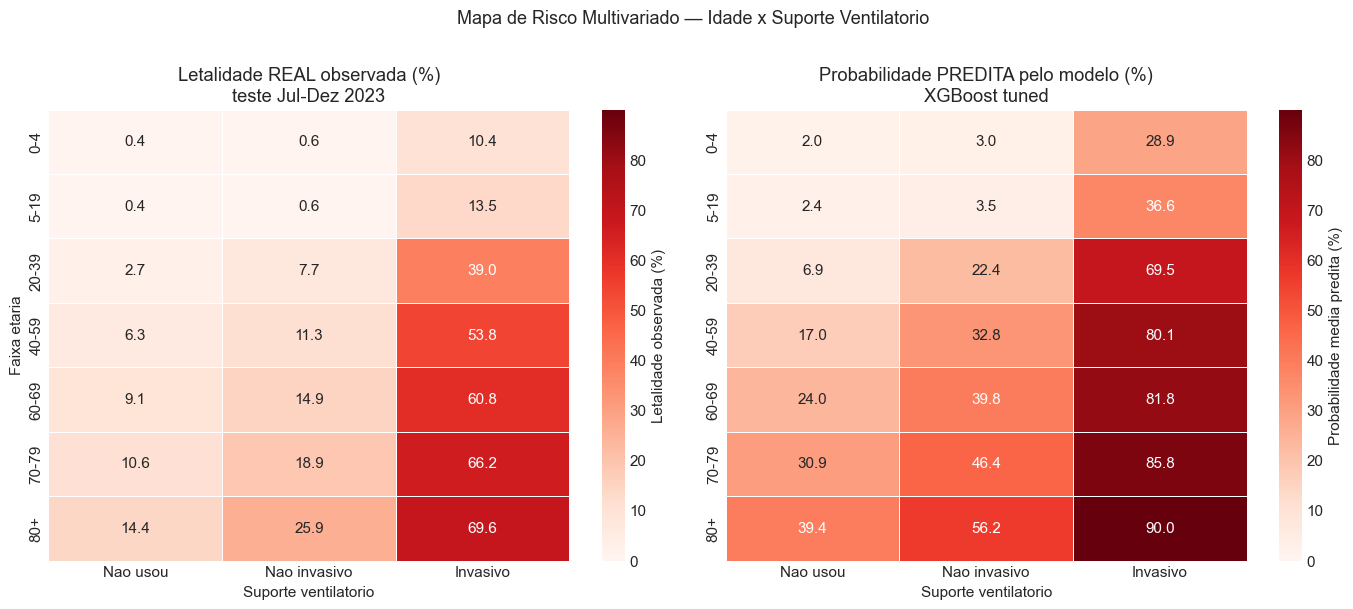

Figura salva: 08_conclusoes/01_mapa_risco_idade_suporte.png

Volume de casos por celula (teste Jul-Dez 2023):
suport_label  Nao usou  Nao invasivo  Invasivo
faixa_etaria                                  
0-4              13361         22536      2673
5-19              4007          7194       771
20-39             1976          1587       633
40-59             2726          3225      1422
60-69             2219          3645      1362
70-79             2578          4835      1457
80+               3500          6810      1361


In [3]:
df_view = X_test.copy()
df_view["proba"] = proba
df_view["target"] = y_test.values

bins_idade = [-1, 4, 19, 39, 59, 69, 79, 120]
labels_idade = ["0-4", "5-19", "20-39", "40-59", "60-69", "70-79", "80+"]
df_view["faixa_etaria"] = pd.cut(df_view["IDADE_ANOS"], bins=bins_idade, labels=labels_idade)

# SUPORT_VEN_ORD: 0=Nao, 1=Nao invasivo, 2=Invasivo (definido em features.py)
map_sv = {0.0: "Nao usou", 1.0: "Nao invasivo", 2.0: "Invasivo"}
df_view["suport_label"] = df_view["SUPORT_VEN_ORD"].map(map_sv)

valid = df_view.dropna(subset=["faixa_etaria", "suport_label"])

# Risco observado real (mortalidade) — referencia para o modelo
real_pivot = valid.pivot_table(index="faixa_etaria", columns="suport_label",
                                values="target", aggfunc="mean", observed=True) * 100
# Risco predito pelo modelo (probabilidade media)
pred_pivot = valid.pivot_table(index="faixa_etaria", columns="suport_label",
                                values="proba", aggfunc="mean", observed=True) * 100
# Tamanho da celula (volume de casos)
n_pivot = valid.pivot_table(index="faixa_etaria", columns="suport_label",
                             values="target", aggfunc="count", observed=True)

col_order = ["Nao usou", "Nao invasivo", "Invasivo"]
real_pivot = real_pivot.reindex(columns=col_order)
pred_pivot = pred_pivot.reindex(columns=col_order)
n_pivot = n_pivot.reindex(columns=col_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax = max(real_pivot.max().max(), pred_pivot.max().max())

sns.heatmap(real_pivot, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=vmax,
            cbar_kws={"label": "Letalidade observada (%)"}, ax=axes[0],
            linewidths=0.4, linecolor="white")
axes[0].set_title("Letalidade REAL observada (%)\nteste Jul-Dez 2023")
axes[0].set_xlabel("Suporte ventilatorio")
axes[0].set_ylabel("Faixa etaria")

sns.heatmap(pred_pivot, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=vmax,
            cbar_kws={"label": "Probabilidade media predita (%)"}, ax=axes[1],
            linewidths=0.4, linecolor="white")
axes[1].set_title("Probabilidade PREDITA pelo modelo (%)\nXGBoost tuned")
axes[1].set_xlabel("Suporte ventilatorio")
axes[1].set_ylabel("")

fig.suptitle("Mapa de Risco Multivariado — Idade x Suporte Ventilatorio",
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_mapa_risco_idade_suporte.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figura salva: 08_conclusoes/01_mapa_risco_idade_suporte.png")
print("\nVolume de casos por celula (teste Jul-Dez 2023):")
print(n_pivot.fillna(0).astype(int).to_string())

**Leitura do mapa de risco — discriminação versus calibração:**

- **Padrão preservado:** ambos os painéis mostram o mesmo gradiente bidimensional. Idade crescente e suporte invasivo caminham juntos para o risco máximo. A **ordenação relativa** (ranking entre células) é praticamente idêntica entre real e predito.
- **Magnitudes superestimadas nas células de alto risco:** a célula **80+ × Invasivo** tem letalidade real de **69,6%**, mas o modelo prediz **90,0%** — superestimação de cerca de 20 pontos percentuais. O mesmo padrão se repete em 60-69 × Invasivo (real 60,8% vs predito 81,8%) e 40-59 × Invasivo (real 53,8% vs predito 80,1%).
- **Magnitudes razoáveis nas células de baixo risco:** 0-4 × Não usou (real 0,4% vs predito 2,0%) e similares têm desvio absoluto pequeno.

**Conclusão prática:** o modelo é eficaz para **ranquear** pacientes (alta AUC-PR e AUC-ROC), mas **não deve ser usado para comunicar probabilidades absolutas** de óbito a leigos sem **recalibração posterior** (Platt scaling ou isotonic regression). Esta é a manifestação visual mais clara do problema de calibração discutido na seção 3 (Brier próximo do baseline).

## 5. Recomendações de Saúde Pública

Cinco intervenções derivadas diretamente dos achados. Cada uma apresenta **(a) racional baseado em dados**, **(b) responsável típico** e **(c) impacto esperado**.

---

### Recomendação 1 — Reforçar capacidade pediátrica de SRAG (UTI e leitos clínicos infantis)

**Racional:** 42% dos casos SRAG 2023 estão em crianças com menos de 5 anos (Insight 1). O pico de maio/2023 (35 mil casos por semana) foi pediátrico. Capacidade adulta de COVID, abundante no pós-pandemia, não cobre essa carga.

**Ação:**
- Mapear leitos pediátricos UTI e clínicos disponíveis por região e simular pico de VSR (modelo histórico SE 17-21).
- Ampliar protocolos de transferência inter-municipal para evitar saturação local em capitais de menor porte.
- Ampliar cobertura de vacinação infantil contra Influenza antes de abril.

**Responsável:** Secretarias estaduais de saúde e Ministério da Saúde (DGSI).
**Impacto esperado:** redução de mortes evitáveis na faixa 0-4 (atualmente 1,2% de letalidade, mas com volume absoluto alto).

---

### Recomendação 2 — Priorização vacinal por perfil idade × comorbidade

**Racional:** o paradoxo de Simpson (Insight 3) mostrou que **a vacinação protege em todos os estratos**, com maior magnitude absoluta em 80+ (diferença real de 10 pontos percentuais). A cobertura no público com mais de 70 anos e 4+ doses ainda é desigual.

**Ação:**
- Cruzar registros do **PNI (Programa Nacional de Imunização)** com **cadastros do SUS** para identificar idosos com mais de 70 anos e menos de 4 doses e priorizar busca ativa.
- Priorizar comorbidades raras e graves (renal, hepática, imuno) — Insight 5 — para reforço anual independente da idade.
- Comunicar usando linguagem estratificada por idade, evitando tabelas marginais confundidoras.

**Responsável:** PNI/Ministério da Saúde e Atenção Primária.
**Impacto esperado:** redução de 5 a 10 pontos percentuais na letalidade do estrato 70+ (replicando o gap observado em 2023).

---

### Recomendação 3 — Sistema de alerta antecipado para semanas e UFs de risco

**Racional:** o modelo (AUC-ROC 0,91) discrimina bem quem morre. Combinado com `SEM_NOT` (top-5 SHAP), pode ser utilizado para **alertar antecipadamente** as semanas e estados de maior pressão.

**Ação:**
- Pipeline semanal: a cada segunda-feira, o modelo processa as fichas SIVEP da semana anterior e emite um **"score regional de SRAG"** — média das probabilidades preditas ponderada por volume.
- Painel público nos moldes do InfoGripe (Fiocruz) com previsão de pico 2 a 4 semanas à frente.
- Threshold operacional Youden (0,319) para acionar alertas em UFs específicas.

**Responsável:** Centro de Operações de Emergências (COE) e Fiocruz/InfoGripe.
**Impacto esperado:** ganho de 2 a 4 semanas de antecipação para alocação de leitos e ventiladores.

---

### Recomendação 4 — Padronizar qualidade do registro SIVEP-Gripe

**Racional:** cerca de 70% de missing em comorbidades não indica que os pacientes não as tinham — indica que a ficha foi preenchida apressadamente. A disparidade de letalidade por UF (AP: 2,4% vs TO: 21,8%) é parcialmente explicada por **qualidade do registro**, não apenas qualidade do cuidado. Isso degrada modelos preditivos e mascara desigualdades reais.

**Ação:**
- Auditoria amostral mensal de fichas SIVEP por UF — meta de menos de 30% de campos "Ignorado" em comorbidades-chave.
- Treinamento de profissionais de notificação em hospitais com piores indicadores de qualidade.
- Implementar **indicadores `_MISS`** (já presentes no pipeline de modelagem) como sinal de qualidade do hospital — não apenas como feature do modelo.

**Responsável:** Coordenação de Vigilância das Doenças e Agravos Não Transmissíveis (SVS/MS) e secretarias estaduais.
**Impacto esperado:** dados de melhor qualidade resultam em modelos mais precisos e vigilância mais justa entre regiões.

---

### Recomendação 5 — Pesquisa direcionada: SRAG por outro agente etiológico em idosos

**Racional:** casos com `CLASSI_FIN=3` (SRAG por outro agente, n próximo de 3.600) apresentam **letalidade desproporcional em 70+ (54-55%)**. Possivelmente coinfecções bacterianas pós-virais ou agentes raros graves. Achado para investigação clínica fora do escopo desta análise.

**Ação:**
- Estudo retrospectivo dirigido com revisão de prontuário em 200 a 300 dessas fichas.
- Coleta sistemática de cultura e PCR ampliado nos casos com 70+ anos, SRAG e teste viral negativo.
- Considerar protocolo de antibioticoterapia empírica precoce em SRAG com 70+ anos enquanto se investiga o agente.

**Responsável:** Instituto Evandro Chagas, redes de hospitais universitários e Sociedades de Pneumologia/Geriatria.
**Impacto esperado:** identificação de agentes tratáveis em uma população de altíssima letalidade.

## 6. Limitações e Próximos Passos

### Limitações conhecidas

1. **Qualidade do registro SIVEP-Gripe.** Cerca de 70% de missing em comorbidades e variação por UF degradam tanto a EDA quanto o modelo. Indicadores `_MISS` mitigam parcialmente — capturam o sinal de "não avaliado" — mas não resolvem o viés.

2. **Features hospitalares como proxy de gravidade.** `SUPORT_VEN_ORD` e `UTI` registram a resposta ao quadro clínico, não apenas o estado de admissão. Um modelo de triagem na chegada exigiria features exclusivamente de pré-internação — projeto separado.

3. **Calibração imperfeita.** Brier próximo do baseline; probabilidades absolutas não devem ser comunicadas a leigos sem recalibração (Platt scaling ou isotonic regression). Recomendado antes de qualquer uso clínico.

4. **Shift de distribuição.** O split temporal captura a sazonalidade 2023 (VSR/Influenza no 1º semestre, COVID no 2º semestre). Generalização para 2024+ exige re-treinamento periódico (recomendado a cada 6 meses) e monitoramento de drift.

5. **Equidade.** Disparidades por raça e região podem refletir disparidade no sinal disponível no registro, não necessariamente viés algorítmico direto. Isso não elimina a preocupação — muda a intervenção necessária (melhorar o registro versus recalibrar o modelo).

6. **Variáveis ausentes.** Status socioeconômico, plano de saúde, distância ao hospital — features potencialmente preditivas que não estão na ficha SIVEP. Limitação estrutural da fonte de dados.

### Próximos passos

1. **Calibração:** Platt scaling ou isotonic regression antes de uso clínico.
2. **Modelo de triagem na chegada** (features de admissão): re-treinar sem `UTI` e `SUPORT_VEN_ORD`. Espera-se AUC-PR menor (possivelmente entre 0,30 e 0,40), mas mais útil operacionalmente.
3. **Pipeline em produção:** containerização (Docker), API REST, dashboard de monitoramento de drift (Evidently ou whylabs).
4. **Validação prospectiva:** aplicar o modelo em casos de 2024 e comparar previsão e realidade — verificar estabilidade da AUC-PR.
5. **Integração com InfoGripe (Fiocruz):** pipeline semanal alimentando o painel público.
6. **Equidade aprofundada:** análise SHAP estratificada por região e métricas de fairness (equal opportunity, demographic parity).

### Reprodutibilidade

Todo o projeto roda do zero com:
```
uv sync
uv run jupyter lab
```
executando os notebooks `01` a `08` em ordem. `random_state` fixo em `config.py` (=42). 29 testes pytest verdes em `tests/test_cleaning.py`.

## Síntese final

> **2023 foi um ano de SRAG pediátrica em volume e SRAG idosa em letalidade.** O modelo (AUC-PR 0,55 / AUC-ROC 0,91) identifica corretamente os óbitos quando há sinais clínicos de gravidade, mas a maior alavanca de saúde pública não está em melhorar mais 1 a 2 pontos percentuais na métrica — está em **(1) vacinar idosos com cobertura de 4+ doses, (2) reforçar capacidade pediátrica antes do pico anual de VSR e (3) padronizar a qualidade do preenchimento do SIVEP-Gripe entre estados**.